Disclaimer: the homework is entirely done manully. But we have used Claude to capture potential mistakes.

In [66]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("../data/project_long_treasury_20260817.xlsx")
specs_data = pd.read_excel(data_path, sheet_name="specs")
long_bond_data = pd.read_excel(
    data_path, sheet_name="long bond", index_col="date", parse_dates=True
)
yields_data = pd.read_excel(
    data_path, sheet_name="yields", index_col="date", parse_dates=True
)
cash_data = pd.read_excel(
    data_path, sheet_name="cash rates", index_col="date", parse_dates=True
)

START = pd.Timestamp("2024-01-02")
END = pd.Timestamp("2026-08-17")

In [67]:
# 1.1


def question_1_1():
    result = {}
    result["ticker"] = specs_data.loc[specs_data["field"] == "ticker", "value"].iloc[0]
    result["issue date"] = pd.to_datetime(
        specs_data.loc[specs_data["field"] == "issue date", "value"].iloc[0]
    )
    result["coupon"] = specs_data.loc[specs_data["field"] == "coupon", "value"].iloc[0]
    result["maturity"] = pd.to_datetime(
        specs_data.loc[specs_data["field"] == "maturity date", "value"].iloc[0]
    )
    result["dirty price"] = long_bond_data.loc[START]["dirty"]
    result["accrued interest"] = long_bond_data.loc[START]["accrued"]
    result["YTM"] = long_bond_data.loc[START]["ytm"]
    result["remaining maturity"] = (result["maturity"] - START).days / 365.25

    result = pd.DataFrame([result])
    print(result.to_string(index=False))


question_1_1()

        ticker issue date  coupon   maturity  dirty price  accrued interest  YTM  remaining maturity
912810RE0 Govt 2014-02-18   3.625 2044-02-15    92.722826          1.379076 4.27           20.120465


A generic 30-year yield is a benchmark, so it always refers to a bond with about 30 years to maturity.

Our bond was issued on 2014-02-18 as a 30-year maturing 2044-02-15, so by 2024-01-02 — ten years later — it has only 20.1 years left.

They are also different kinds of objects: the bond is a security with a fixed 3.625% coupon and a price you can buy and mark, while the generic 30-year is only a quoted rate.

Comparing the two on the same day, this bond yields 4.27 against the benchmark's 4.0708.

In [126]:
# 1.2


def question_1_2():
    three = long_bond_data.head(3).copy()
    three["clean + accrued"] = three["clean"] + three["accrued"]
    three["price gap"] = three["clean + accrued"] - three["dirty"]
    print(
        three[["clean", "accrued", "dirty", "clean + accrued", "price gap"]].to_string()
    )
    print()
    coupon_dates = len(
        long_bond_data[long_bond_data["coupon cash"] != 0]["coupon cash"]
    )
    print(f"There are {coupon_dates} coupon days.\n")
    # baseline is 100%
    # t+1's dirty + coupon / t's dirty
    tri_0 = 1
    for i in range(2):
        next_row = long_bond_data.iloc[i + 1]
        tri_1 = (
            tri_0
            * (next_row["dirty"] + next_row["coupon cash"])
            / long_bond_data.iloc[i]["dirty"]
        )
        tri_0 = tri_1
        print(
            f"{long_bond_data.index[i+1].date()}'s computed total return index is {tri_1:.4%} comparing to data in the excel {next_row['total return index']:.4f}%."
        )


question_1_2()

                clean   accrued      dirty  clean + accrued  price gap
date                                                                  
2024-01-02  91.343750  1.379076  92.722826        92.722826        0.0
2024-01-03  91.484375  1.388927  92.873302        92.873302        0.0
2024-01-04  90.484375  1.398777  91.883152        91.883152        0.0

There are 6 coupon days.

2024-01-03's computed total return index is 100.1623% comparing to data in the excel 100.1623%.
2024-01-04's computed total return index is 99.0944% comparing to data in the excel 99.0944%.


Index formula: TRI_{T+1} = TRI_T × (dirty_{T+1} + coupon_{T+1}) / dirty_T, starting at 100.

Jan 2, Jan 3 has no coupon, so the index return equals the dirty return TRI_{T+1} = TRI_T × dirty_{T+1} / dirty_T.

on coupon dates accrued resets to 0 and dirty drops by about the coupon, so a dirty-price return shows a loss that didn't happen.

On 2024-02-15 dirty fell −1.643%, but the holder got 1.8125 cash; adding it back gives +0.387% — exactly the index return. 

Six such dates in the sample.

Yields on 2024-01-02 are:
2y     4.3201
10y    3.9294
30y    4.0708

historical percentile of the 30-year yield on 2024-01-02 00:00:00 is 55.9593%

Slopes on 2024-01-02 are:
2s10s    -0.3907
10s30s    0.1414


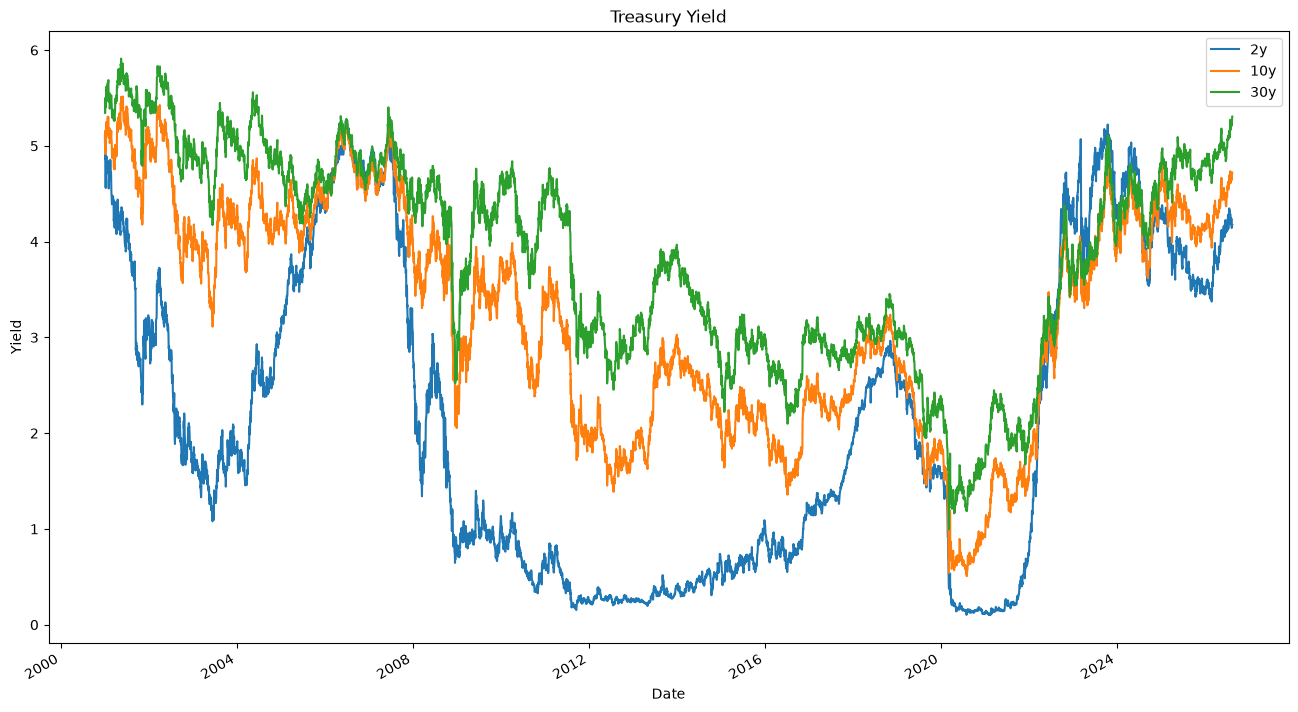

In [125]:
# 2.1


def question_2_1():
    yields_data.plot(
        figsize=(16, 9), title="Treasury Yield", xlabel="Date", ylabel="Yield"
    )

    three_yield = yields_data.loc[START]
    print(f"Yields on {START.date()} are:\n{three_yield.to_string()}\n")

    hist = yields_data["30y"].loc[:START]
    perc = (hist <= yields_data["30y"].loc[START]).mean()
    print(f"historical percentile of the 30-year yield on {START} is {perc:.4%}\n")

    # 2s10s is 10-year yield - 2-year yield
    slope_2s10s = (yields_data["10y"] - yields_data["2y"]).rename("2s10s")
    slope_10s30s = (yields_data["30y"] - yields_data["10y"]).rename("10s30s")
    slope = pd.concat([slope_2s10s, slope_10s30s], axis=1)
    print(f"Slopes on {START.date()} are:\n{slope.loc[START].to_string()}")


question_2_1()

cash rates on min YTM date 2024-09-16 00:00:00 are:
3m Treasury    4.8609
SOFR           5.3800
cash rates on max YTM date 2026-08-17 00:00:00 are:
3m Treasury    3.7817
SOFR           3.6600


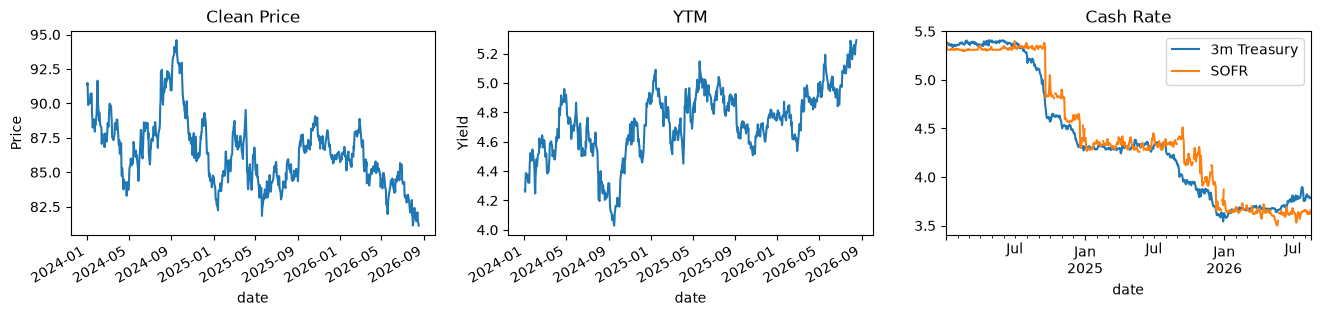

In [70]:
# 2.2

max_ytm_date = None
min_ytm_date = None


def question_2_2():
    global max_ytm_date, min_ytm_date
    _, axes = plt.subplots(1, 3, figsize=(16, 3))
    clean = long_bond_data.loc[START:END]["clean"]
    ytm = long_bond_data.loc[START:END]["ytm"]
    clean.plot(ax=axes[0], title="Clean Price", ylabel="Price")
    ytm.plot(ax=axes[1], title="YTM", ylabel="Yield")
    cash_data.plot(ax=axes[2], title="Cash Rate")

    max_ytm_date = ytm.idxmax()
    min_ytm_date = ytm.idxmin()
    print(
        f"cash rates on min YTM date {min_ytm_date} are:\n{cash_data.loc[min_ytm_date].to_string()}"
    )
    print(
        f"cash rates on max YTM date {max_ytm_date} are:\n{cash_data.loc[max_ytm_date].to_string()}"
    )


question_2_2()

The two extremes of the plotted range are 2024-09-16 at YTM 4.029 and clean 94.59, and 2026-08-17 at YTM 5.292 and clean 81.13.

2024-09-16 is a few days before the first Fed cut. Yields were at their lowest, so the price was at its highest, and cash paid more than the bond (SOFR 5.38 against a YTM of 4.029). Buying there means paying the most for the bond while earning less than cash.

2026-08-17 is the opposite: the bond is at its cheapest and cash has fallen to 3.66, so the bond now yields more than cash.

The two dates give different answers to whether the bond beat cash. 2026-08-17 is also the last day of the data, so you can't buy there and hold anything.

In [ ]:
# 3.1

BUY_DATE = pd.Timestamp("2024-09-16")


def question_3_1():
    print(f"purchase date = {BUY_DATE.date()}")
    print(
        long_bond_data.loc[BUY_DATE, ["clean", "accrued", "dirty", "ytm"]].to_string()
    )
    print(yields_data.loc[BUY_DATE].to_string())
    print(cash_data.loc[BUY_DATE].to_string())


question_3_1()

purchase date = 2024-09-16
clean      94.593750
accrued     0.315217
dirty      94.908967
ytm         4.029000
2y     3.5509
10y    3.6176
30y    3.9285
3m Treasury    4.8609
SOFR           5.3800


We picked 2024-09-16, the trading day before the September 2024 FOMC, because it sits at the turn of the rate cycle.

SOFR was 5.38 while the bond yielded 4.029. Cash paid 135bp more because SOFR reflects the rate the Fed hadn't cut yet, while the long end had already priced the cuts in.

We chose SOFR over 3m Treasury because the alternative to holding the bond is rolling cash overnight, and SOFR is what you earn doing that.

Known that day: the market expected a cut.

Known only with hindsight: this was the lowest yield of the whole sample.

So this is a conditional example of what a buyer at that moment got, not a rule you could have followed in advance.

In [ ]:
# 3.2


def bond_return(start):
    backtest_windows = long_bond_data.loc[start:END]
    result = {}
    result["start dirty price"] = backtest_windows.iloc[0]["dirty"]
    result["end dirty price"] = backtest_windows.iloc[-1]["dirty"]
    result["total"] = (
        backtest_windows.iloc[-1]["total return index"]
        / backtest_windows.iloc[0]["total return index"]
        - 1
    )
    result["dirty"] = (
        backtest_windows.iloc[-1]["dirty"] - backtest_windows.iloc[0]["dirty"]
    ) / backtest_windows.iloc[0]["dirty"]
    # note this is reinvested so we can't use coupon cash.sum()
    # compute this backward
    result["residual"] = (1 + result["total"]) / (1 + result["dirty"]) - 1
    result = pd.DataFrame([result])
    return result


def print_bond_return(df):
    print(
        df.to_string(
            index=False,
            formatters={
                "total": "{:.4%}".format,
                "dirty": "{:.4%}".format,
                "residual": "{:.4%}".format,
            },
        )
    )


def question_3_2():
    global BUY_DATE
    result = bond_return(BUY_DATE)
    print_bond_return(result)


question_3_2()

 start dirty price  end dirty price    total     dirty residual
         94.908967        81.152514 -6.9463% -14.4944%  8.8276%


In [133]:
# 4.1


BENCH = "SOFR"


def cash_return(start, benchmark):
    rate = cash_data.loc[start:END, benchmark].ffill() / 100
    days = rate.index.to_series().diff().dt.days.fillna(0)
    growth = 1 + rate.shift(1).fillna(0) * days / 360
    return growth.cumprod()


def question_4_1():
    global BUY_DATE, BENCH
    ret = cash_return(BUY_DATE, BENCH)
    print(
        f"From {BUY_DATE.date()} to {END.date()}: cumulative cash return = {ret.iloc[-1] - 1:.4%}"
    )


question_4_1()

From 2024-09-16 to 2026-08-17: cumulative cash return = 8.3304%


The roll uses SOFR on actual/360 with daily compounding, and each day's rate is applied to the following interval only, so nothing is earned on a rate that had not yet printed. 

Weekend and holiday gaps accrue at the last observed rate over actual calendar days, which is how an overnight repo position actually rolls. That returns 8.33% over the same dates.

In [120]:
# 4.2


def performance(level, name):
    ret = level.pct_change().dropna()
    result = {}
    result["total"] = level.iloc[-1] / level.iloc[0] - 1
    result["annual volatility"] = ret.std() * (252**0.5)
    result["maximum drawdown"] = (level / level.cummax() - 1).min()

    result = pd.DataFrame([result])
    result_str = result.to_string(
        index=False,
        formatters={
            "total": "{:.4%}".format,
            "annual volatility": "{:.4%}".format,
            "maximum drawdown": "{:.4%}".format,
        },
    )
    print(f"Performance result for {name}:\n{result_str}\n")


def question_4_2():
    global BUY_DATE, BENCH
    performance(long_bond_data.loc[BUY_DATE:END, "total return index"], "bond")
    performance(cash_return(BUY_DATE, BENCH), f"{BENCH} roll")


question_4_2()

Performance result for bond:
   total annual volatility maximum drawdown
-6.9463%           9.5567%        -11.7686%

Performance result for SOFR roll:
  total annual volatility maximum drawdown
8.3304%           0.1475%          0.0000%



Cash returned +8.33% against the bond's −6.95%, so cash won by 15.3 points, with 0.1475% volatility and 0 drawdown against the bond's 9.56% and −11.77%.

This does not support the reason for buying on 2024-09-16. Locking in 4.029% before the cuts failed twice: long yields rose to 5.292% anyway, costing 14.49% on price, and cash still paid more interest than 4.029% for the first 60% of the period, only falling below it in November 2025.

In [124]:
# 5.1


def question_5_1():
    global BUY_DATE
    table = yields_data.loc[[BUY_DATE, END]].copy()
    table.loc["yield change"] = table.loc[END] - table.loc[BUY_DATE]
    print(table.to_string())
    y30 = yields_data.loc[END, "30y"]
    print(f"The assessment-date percentile of the 30-year yield is {(yields_data['30y'] <= y30).mean():.4%}")


question_5_1()

                         2y     10y     30y
date                                       
2024-09-16 00:00:00  3.5509  3.6176  3.9285
2026-08-17 00:00:00  4.1753  4.7219  5.3060
yield change         0.6244  1.1043  1.3775
The assessment-date percentile of the 30-year yield is 93.5479%


In [127]:
# 5.2


def question_5_2():
    y10 = yields_data["10y"].dropna()
    level = y10
    change = y10.diff().dropna()
    rows = []
    # day, week, month, quarter since weekend is omitted
    # autocorr is just x.corr(x.shift(lag))
    for lag in [1, 5, 21, 63]:
        rows.append(
            {
                "lag (days)": lag,
                "autocorr level": level.autocorr(lag),
                "autocorr change": change.autocorr(lag),
            }
        )
    print(pd.DataFrame(rows).to_string(index=False))


question_5_2()

 lag (days)  autocorr level  autocorr change
          1        0.998804        -0.044741
          5        0.994727        -0.017554
         21        0.977944         0.021336
         63        0.932626         0.014592


We measure persistence the same way for both: the correlation between today's value and the value some days earlier.

The 10-year level scores 0.999 one day back and still 0.933 a quarter back. Its daily change scores −0.045 one day back and roughly zero after that. So the level stays where it is, while daily moves are unpredictable.

The article gives several reasons the level is high: deficits, heavy corporate and AI borrowing, and uncertainty under Warsh. We pick the fiscal one — Barclays says the worsening fiscal profile will "keep long-term yields elevated," a claim about the level staying put, which is what we measure.

The article says nothing about the change being uncorrelated, and none of its explanations would predict daily moves either. That is also why the workbook cannot say which cause it is: all three fit the same numbers, and none of them appears in the data.

In [135]:
# 6.1


def question_6_1():
    ALT_BUY = pd.Timestamp("2025-01-21")
    global BUY_DATE, BENCH
    print(
        f"alternative purchase date = {ALT_BUY.date()} "
        f"({(ALT_BUY - BUY_DATE).days} days after {BUY_DATE.date()})"
    )
    print(
        long_bond_data.loc[[BUY_DATE, ALT_BUY], ["clean", "dirty", "ytm"]].to_string()
    )
    print()
    result = bond_return(ALT_BUY)
    print_bond_return(result)
    print()
    ret = cash_return(ALT_BUY, BENCH)
    print(
        f"From {ALT_BUY.date()} to {END.date()}: cumulative cash return = {ret.iloc[-1] - 1:.4%}"
    )
    print()
    performance(long_bond_data.loc[ALT_BUY:END, "total return index"], "bond")
    performance(cash_return(ALT_BUY, BENCH), f"{BENCH} roll")


question_6_1()

alternative purchase date = 2025-01-21 (127 days after 2024-09-16)
                clean      dirty    ytm
date                                   
2024-09-16  94.593750  94.908967  4.029
2025-01-21  84.203125  85.769361  4.910

 start dirty price  end dirty price   total    dirty residual
         85.769361        81.152514 2.9695% -5.3829%  8.8276%

From 2025-01-21 to 2026-08-17: cumulative cash return = 6.5704%

Performance result for bond:
  total annual volatility maximum drawdown
2.9695%           9.3165%         -8.0263%

Performance result for SOFR roll:
  total annual volatility maximum drawdown
6.5704%           0.1431%          0.0000%



Entering on 2025-01-21 at YTM 4.91 and dirty 85.769 turns the cumulative bond return from -6.95% to +2.97%, so the sign of the bond result flips. What survives is the ranking: the SOFR roll still wins, 6.57% against 2.97%, with 0.15% volatility against 9.32% and no drawdown against -8.03%.

The coupon residual is identical at 8.83% because both entries cross the same four remaining coupon dates, so the entire difference is the entry price.

Paying 94.909 for a 4.03% yield versus 85.769 for a 4.91% yield is 88bp of extra carry plus a nine-point-lower starting price against the same 5.29% exit, which is the whole gap.

In [142]:
# 6.2


def question_6_2():
    y = long_bond_data.loc[END, "ytm"] / 100
    spot = cash_data.loc[END, BENCH] / 100
    coupon = float(specs_data.loc[specs_data["field"] == "coupon", "value"].iloc[0])
    maturity = pd.to_datetime(
        specs_data.loc[specs_data["field"] == "maturity date", "value"].iloc[0]
    )
    n = round((maturity - END).days / 182.625)

    # our sample: SOFR fell this much while the bond's yield rose this much
    cut_so_far = (cash_data.loc[END, BENCH] - cash_data.loc[BUY_DATE, BENCH]) / 100
    ytm_so_far = (long_bond_data.loc[END, "ytm"] - long_bond_data.loc[BUY_DATE, "ytm"]) / 100
    passthrough = ytm_so_far / cut_so_far
    print(f"since {BUY_DATE.date()}: {BENCH} {cut_so_far*1e4:+.0f}bp, bond YTM {ytm_so_far*1e4:+.0f}bp")
    print(f"so each 100bp of cut came with {-passthrough*100:+.0f}bp on the bond's yield\n")

    def price(rate, periods):
        k = pd.Series(range(1, periods + 1))
        cf = pd.Series([coupon / 2] * periods)
        cf.iloc[-1] += 100
        return (cf / (1 + rate / 2) ** k).sum()

    start = price(y, n)
    rows = {}
    for cut in [0.0000, 0.0025, 0.0050, 0.0075, 0.0100]:
        new_y = y - passthrough * cut  # cut pushes the long yield the other way
        rows[f"{cut*1e4:.0f}bp"] = {
            "hold the bond": (price(new_y, n - 2) + coupon) / start - 1,
            f"roll {BENCH}": (1 + (spot - cut / 2) / 360) ** 365 - 1,
        }
    table = pd.DataFrame(rows).T
    table.index.name = "Fed cut over the year"
    print(table.to_string(formatters={c: "{:.4%}".format for c in table.columns}))

question_6_2()

since 2024-09-16: SOFR -172bp, bond YTM +126bp
so each 100bp of cut came with +73bp on the bond's yield

                      hold the bond roll SOFR
Fed cut over the year                        
0bp                         5.3029%   3.7803%
25bp                        3.1564%   3.6489%
50bp                        1.0672%   3.5177%
75bp                       -0.9662%   3.3866%
100bp                      -2.9456%   3.2556%


I sell the bond and roll SOFR, horizon one year from 2026-08-17.

The assumption the choice requires is that cuts keep pushing the long yield the wrong way. In our sample SOFR fell 172bp while the bond's yield rose 126bp, so each 100bp of cut came with 73bp added to the bond's yield. Carrying that forward, a cut takes a little off cash and a lot off the bond, because the price falls faster than the coupon can cover.

The table is the answer. With no cut the bond wins, 5.30% against 3.78%. A 25bp cut already flips it, and a 100bp cut leaves the bond at −2.95% against 3.26% for cash. Section 4 is the same result already realized: a buyer at the September 2024 low took −6.95% while the roll made +8.33%, through a cycle in which the Fed cut 172bp.

What the workbook cannot establish is that the 73bp holds. It is one episode, and week to week the two rates barely move together, so this is borrowed from 2024–2026 rather than measured. The observable that reverses the decision is the next cut arriving without the long end selling off — a 30-year yield falling below today's 5.306% while SOFR comes down would say the link is broken and the bond is back ahead.